# テキストのストレス判定：手法比較実験

**目標**：SNS 投稿テキストが「読む人にストレスを与えるか」を自動判定するための手法を比較する。

有害コンテンツの除去（侮辱・脅迫）とは区別し、より広い意味での **ストレス誘発** を対象にする。  
例：悲観的な内容、不安を煽る表現、比較・FOMO（乗り遅れ恐怖）、怒りの表現など。

## 比較する手法

| # | 手法 | 概要 | 日本語 | オフライン |
|---|------|------|--------|------------|
| 1 | ルールベース | キーワード・正規表現 | ○ | ○ |
| 2 | 極性辞書（oseti） | 形態素解析 + 極性スコア | ○ | ○ |
| 3 | 感情分析モデル（多言語） | Transformers 2値分類 | ○ | ○ |
| 4 | 感情分類モデル（7種） | anger/fear/sadness 等 | △（英語） | ○ |
| 5 | ゼロショット（名詞句ラベル） | NLI + カテゴリ名 | ○ | ○ |
| 6 | ゼロショット（仮説文ラベル） | NLI + 文章型ラベル | ○ | ○ |
| 7 | アンサンブル | 複数手法の組み合わせ | ○ | ○ |


## セットアップ

In [ ]:
# 必要なパッケージをインストール
# ※ SNS Research (Python 3.10) カーネルで実行してください
# ※ oseti と mecab-python3 は .venv に事前インストール済み
#    → research/.venv/bin/pip install oseti mecab-python3 unidic-lite
%pip install -q transformers torch sentencepiece
%pip install -q pandas matplotlib seaborn

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from transformers import pipeline

matplotlib.rcParams['font.family'] = 'Hiragino Sans'  # macOS 日本語フォント
# Windows の場合: 'MS Gothic'
# Linux の場合:   'IPAGothic'

print('セットアップ完了')

セットアップ完了


## テストデータ

ストレス誘発の種類ごとにサンプルを用意する。

| カテゴリ | 説明 |
|----------|------|
| `toxic` | 明示的な攻撃・侮辱 |
| `negative_emotion` | 悲しみ・絶望・怒りの表現 |
| `fomo` | 乗り遅れ恐怖・焦りを誘発 |
| `comparison` | 比較・マウント・嫉妬誘発 |
| `anxiety` | 不安・恐怖を煽る |
| `neutral` | 中立的な内容 |
| `positive` | ポジティブな内容 |

In [3]:
samples = [
    # --- toxic（明示的な攻撃）---
    {"text": "お前なんか消えてしまえ、存在価値がない", "category": "toxic", "lang": "ja"},
    {"text": "You are absolutely worthless, just disappear.", "category": "toxic", "lang": "en"},

    # --- negative_emotion（悲しみ・絶望）---
    {"text": "もう何もかもが嫌になった。毎日がつらくて仕方ない", "category": "negative_emotion", "lang": "ja"},
    {"text": "今日も最悪な一日だった。何をやってもうまくいかない", "category": "negative_emotion", "lang": "ja"},
    {"text": "I feel so empty and exhausted. Nothing seems worth it anymore.", "category": "negative_emotion", "lang": "en"},
    {"text": "この先どうなるんだろう、不安で眠れない夜が続いている", "category": "negative_emotion", "lang": "ja"},

    # --- fomo（乗り遅れ恐怖）---
    {"text": "みんなもうあれ買ったの？まだ持ってないの自分だけじゃない？", "category": "fomo", "lang": "ja"},
    {"text": "今すぐやらないと乗り遅れる！このチャンスは今だけ", "category": "fomo", "lang": "ja"},
    {"text": "Everyone's already doing this. Are you still not on board? You're missing out big time.", "category": "fomo", "lang": "en"},

    # --- comparison（比較・マウント）---
    {"text": "同期がもう部長に昇進したらしい。自分はまだヒラのまま…", "category": "comparison", "lang": "ja"},
    {"text": "年収1000万超えてる人って普通にいるんだな。自分と何が違うんだろう", "category": "comparison", "lang": "ja"},
    {"text": "At 25 I already own three properties. Most people my age are still renting. Work harder!", "category": "comparison", "lang": "en"},

    # --- anxiety（不安・恐怖を煽る）---
    {"text": "このまま日本経済が崩壊したらどうなるの？老後の蓄えが全部消えるかも", "category": "anxiety", "lang": "ja"},
    {"text": "AIに仕事を全部奪われる時代が来る。あなたの職業は10年後に存在しないかも", "category": "anxiety", "lang": "ja"},
    {"text": "The world is falling apart and nobody seems to care. We're all doomed.", "category": "anxiety", "lang": "en"},

    # --- neutral（中立）---
    {"text": "今日は晴れていたので公園を散歩した", "category": "neutral", "lang": "ja"},
    {"text": "新しいカフェがオープンしたので行ってみた。コーヒーがおいしかった", "category": "neutral", "lang": "ja"},
    {"text": "Just finished reading a book about history. Pretty interesting.", "category": "neutral", "lang": "en"},

    # --- positive（ポジティブ）---
    {"text": "今日は大好きな友達と久しぶりに会えて、すごく楽しかった！", "category": "positive", "lang": "ja"},
    {"text": "長年の夢だった資格試験に合格した。諦めなくてよかった", "category": "positive", "lang": "ja"},
    {"text": "Had the most wonderful day with family. Feeling truly grateful and happy.", "category": "positive", "lang": "en"},
]

df = pd.DataFrame(samples)
print(f'サンプル数: {len(df)}')
df.groupby('category').size()

サンプル数: 21


category
anxiety             3
comparison          3
fomo                3
negative_emotion    4
neutral             3
positive            3
toxic               2
dtype: int64

---
## 手法 1：ルールベース（キーワード・正規表現）

**特徴**：実装が最も簡単。オフライン・ゼロレイテンシ。  
**限界**：文脈を無視する。「死ぬほど楽しい」のような慣用句を誤検知する。

In [4]:
# ストレス誘発キーワードリスト（有害コンテンツ以外も含む）
STRESS_KEYWORDS = [
    # 有害・攻撃
    '消えろ', '死ね', '殺す', 'クズ', 'ゴミ', '最低',
    # 悲しみ・絶望
    'つらい', 'つらくて', 'もう嫌', '嫌になった', '眠れない', '疲れた', '限界',
    # 不安・恐怖
    '不安', '怖い', '崩壊', '消えるかも', '存在しない', '奪われる',
    # FOMO・比較
    '乗り遅れ', '自分だけ', 'まだ持ってない', '何が違う',
]

STRESS_PATTERNS = [
    re.compile(r'もう.{0,5}(嫌|限界|無理|ダメ)'),
    re.compile(r'(自分|俺|私).{0,10}(だけ|ばかり|しか)'),
    re.compile(r'(消え|なくな|終わ).{0,5}(かも|そう|る)'),
    re.compile(r'\b(doomed|worthless|exhausted|empty|awful|hate)\b', re.IGNORECASE),
]

def rule_based_stress(text: str) -> dict:
    lower = text.lower()
    matched_kw = [kw for kw in STRESS_KEYWORDS if kw in lower]
    matched_pt = [p.pattern for p in STRESS_PATTERNS if p.search(text)]
    score = min(1.0, (len(matched_kw) * 0.3 + len(matched_pt) * 0.4))
    return {
        'score': round(score, 2),
        'flagged': score > 0,
        'matched': matched_kw + matched_pt
    }

df['rule_score'] = df['text'].apply(lambda t: rule_based_stress(t)['score'])
df['rule_flagged'] = df['text'].apply(lambda t: rule_based_stress(t)['flagged'])

print('=== ルールベース 検出結果 ===')
for _, row in df.iterrows():
    flag = '🔴' if row['rule_flagged'] else '⚪'
    print(f"{flag} [{row['category']:18s}] {row['text'][:40]}")

=== ルールベース 検出結果 ===
⚪ [toxic             ] お前なんか消えてしまえ、存在価値がない
🔴 [toxic             ] You are absolutely worthless, just disap
🔴 [negative_emotion  ] もう何もかもが嫌になった。毎日がつらくて仕方ない
⚪ [negative_emotion  ] 今日も最悪な一日だった。何をやってもうまくいかない
🔴 [negative_emotion  ] I feel so empty and exhausted. Nothing s
🔴 [negative_emotion  ] この先どうなるんだろう、不安で眠れない夜が続いている
🔴 [fomo              ] みんなもうあれ買ったの？まだ持ってないの自分だけじゃない？
🔴 [fomo              ] 今すぐやらないと乗り遅れる！このチャンスは今だけ
⚪ [fomo              ] Everyone's already doing this. Are you s
⚪ [comparison        ] 同期がもう部長に昇進したらしい。自分はまだヒラのまま…
🔴 [comparison        ] 年収1000万超えてる人って普通にいるんだな。自分と何が違うんだろう
⚪ [comparison        ] At 25 I already own three properties. Mo
🔴 [anxiety           ] このまま日本経済が崩壊したらどうなるの？老後の蓄えが全部消えるかも
🔴 [anxiety           ] AIに仕事を全部奪われる時代が来る。あなたの職業は10年後に存在しないかも
🔴 [anxiety           ] The world is falling apart and nobody se
⚪ [neutral           ] 今日は晴れていたので公園を散歩した
⚪ [neutral           ] 新しいカフェがオープンしたので行ってみた。コーヒーがおいしかった
⚪ [neutral           ] Just finished reading 

---
## 手法 2：極性辞書（oseti）

**特徴**：日本語形態素解析 + 東北大の極性辞書。単語レベルで感情極性を算出。  
**限界**：辞書にない新語・スラングに弱い。文脈を無視する。  
**要件**：`oseti` と MeCab が必要（`pip install oseti mecab-python3 unidic-lite`）

In [ ]:
try:
    import oseti
    analyzer = oseti.Analyzer()

    def oseti_stress(text: str) -> dict:
        scores = analyzer.analyze(text)
        if not scores:
            return {'score': 0.0, 'flagged': False}
        avg = sum(scores) / len(scores)
        # oseti は -1（ネガ）〜 +1（ポジ）を返す
        # ストレス = ネガティブ → -avg を正規化
        normalized = max(0.0, -avg)
        return {'score': round(normalized, 2), 'flagged': normalized > 0.3}

    df['oseti_score'] = df['text'].apply(lambda t: oseti_stress(t)['score'])
    df['oseti_flagged'] = df['text'].apply(lambda t: oseti_stress(t)['flagged'])

    print('=== oseti 検出結果 ===')
    for _, row in df.iterrows():
        flag = '🔴' if row['oseti_flagged'] else '⚪'
        print(f"{flag} [{row['category']:18s}] score={row['oseti_score']:.2f}  {row['text'][:35]}")

except ImportError:
    print('⚠ oseti が未インストールです。')
    print('ターミナルで以下を実行してください（SNS Research カーネルを使用中の場合）:')
    print('  cd research && .venv/bin/pip install oseti mecab-python3 unidic-lite')
    print('その後、カーネルを再起動してこのセルを再実行してください。')
    df['oseti_score'] = float('nan')
    df['oseti_flagged'] = float('nan')

---
## 手法 3：感情分析モデル（多言語 Transformer）

**モデル**：`lxyuan/distilbert-base-multilingual-cased-sentiments-student`  
**特徴**：日本語・英語など多言語対応。`positive / neutral / negative` の3値スコアを返す。  
**サイズ**：約 270MB（初回ダウンロード後はキャッシュ）  
**限界**：細かい感情カテゴリの区別はできない。

In [6]:
print('モデルを読み込み中... (初回は時間がかかります)')
sentiment_pipeline = pipeline(
    'text-classification',
    model='lxyuan/distilbert-base-multilingual-cased-sentiments-student',
    top_k=None  # すべてのラベルのスコアを返す
)
print('読み込み完了')

def sentiment_stress(text: str) -> dict:
    results = sentiment_pipeline(text[:512], truncation=True)
    score_map = {r['label']: r['score'] for r in results[0]}
    neg_score = score_map.get('negative', 0.0)
    return {
        'negative': round(neg_score, 3),
        'neutral':  round(score_map.get('neutral', 0.0), 3),
        'positive': round(score_map.get('positive', 0.0), 3),
        'flagged': neg_score > 0.5
    }

results3 = df['text'].apply(sentiment_stress)
df['sent_neg'] = results3.apply(lambda r: r['negative'])
df['sent_flagged'] = results3.apply(lambda r: r['flagged'])

print('\n=== 感情分析（多言語）検出結果 ===')
for _, row in df.iterrows():
    flag = '🔴' if row['sent_flagged'] else '⚪'
    print(f"{flag} [{row['category']:18s}] neg={row['sent_neg']:.3f}  {row['text'][:35]}")

モデルを読み込み中... (初回は時間がかかります)


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

読み込み完了

=== 感情分析（多言語）検出結果 ===
⚪ [toxic             ] neg=0.415  お前なんか消えてしまえ、存在価値がない
⚪ [toxic             ] neg=0.309  You are absolutely worthless, just 
🔴 [negative_emotion  ] neg=0.810  もう何もかもが嫌になった。毎日がつらくて仕方ない
🔴 [negative_emotion  ] neg=0.902  今日も最悪な一日だった。何をやってもうまくいかない
🔴 [negative_emotion  ] neg=0.708  I feel so empty and exhausted. Noth
⚪ [negative_emotion  ] neg=0.458  この先どうなるんだろう、不安で眠れない夜が続いている
⚪ [fomo              ] neg=0.457  みんなもうあれ買ったの？まだ持ってないの自分だけじゃない？
⚪ [fomo              ] neg=0.493  今すぐやらないと乗り遅れる！このチャンスは今だけ
🔴 [fomo              ] neg=0.513  Everyone's already doing this. Are 
⚪ [comparison        ] neg=0.393  同期がもう部長に昇進したらしい。自分はまだヒラのまま…
⚪ [comparison        ] neg=0.412  年収1000万超えてる人って普通にいるんだな。自分と何が違うんだろう
⚪ [comparison        ] neg=0.438  At 25 I already own three propertie
🔴 [anxiety           ] neg=0.760  このまま日本経済が崩壊したらどうなるの？老後の蓄えが全部消えるかも
🔴 [anxiety           ] neg=0.580  AIに仕事を全部奪われる時代が来る。あなたの職業は10年後に存在しない
🔴 [anxiety           ] neg=0.748  The world is falling apart and

---
## 手法 4：感情分類モデル（7種類の感情）

**モデル**：`j-hartmann/emotion-english-distilroberta-base`  
**感情ラベル**：`anger / disgust / fear / joy / neutral / sadness / surprise`  
**特徴**：ストレスに関連する感情（anger・fear・sadness・disgust）を個別に識別できる。  
**限界**：英語専用。日本語投稿には英訳が必要（別途 translation pipeline が要る）。

In [7]:
print('感情分類モデルを読み込み中...')
emotion_pipeline = pipeline(
    'text-classification',
    model='j-hartmann/emotion-english-distilroberta-base',
    top_k=None
)
print('読み込み完了')

# ストレスに関連する感情の重みづけ
STRESS_WEIGHT = {
    'anger':   1.0,
    'fear':    0.9,
    'sadness': 0.8,
    'disgust': 0.7,
    'surprise': 0.2,
    'neutral':  0.0,
    'joy':      0.0,
}

def emotion_stress(text: str) -> dict:
    # 英語テキストのみ対象（日本語は skip）
    results = emotion_pipeline(text[:512], truncation=True)
    score_map = {r['label']: r['score'] for r in results[0]}
    stress_score = sum(score_map.get(e, 0) * w for e, w in STRESS_WEIGHT.items())
    top_emotion = max(score_map, key=score_map.get)
    return {
        'stress_score': round(stress_score, 3),
        'top_emotion': top_emotion,
        'scores': {e: round(s, 3) for e, s in score_map.items()},
        'flagged': stress_score > 0.4
    }

results4 = df['text'].apply(emotion_stress)
df['emotion_score'] = results4.apply(lambda r: r['stress_score'])
df['top_emotion'] = results4.apply(lambda r: r['top_emotion'])
df['emotion_flagged'] = results4.apply(lambda r: r['flagged'])

print('\n=== 感情分類（7種）検出結果 ===')
for _, row in df.iterrows():
    flag = '🔴' if row['emotion_flagged'] else '⚪'
    print(f"{flag} [{row['category']:18s}] score={row['emotion_score']:.3f} top={row['top_emotion']:8s}  {row['text'][:30]}")

感情分類モデルを読み込み中...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

読み込み完了

=== 感情分類（7種）検出結果 ===
⚪ [toxic             ] score=0.218 top=neutral   お前なんか消えてしまえ、存在価値がない
🔴 [toxic             ] score=0.493 top=neutral   You are absolutely worthless, 
⚪ [negative_emotion  ] score=0.237 top=neutral   もう何もかもが嫌になった。毎日がつらくて仕方ない
⚪ [negative_emotion  ] score=0.283 top=neutral   今日も最悪な一日だった。何をやってもうまくいかない
🔴 [negative_emotion  ] score=0.794 top=sadness   I feel so empty and exhausted.
⚪ [negative_emotion  ] score=0.201 top=neutral   この先どうなるんだろう、不安で眠れない夜が続いている
⚪ [fomo              ] score=0.301 top=neutral   みんなもうあれ買ったの？まだ持ってないの自分だけじゃない？
⚪ [fomo              ] score=0.221 top=neutral   今すぐやらないと乗り遅れる！このチャンスは今だけ
⚪ [fomo              ] score=0.392 top=neutral   Everyone's already doing this.
⚪ [comparison        ] score=0.231 top=neutral   同期がもう部長に昇進したらしい。自分はまだヒラのまま…
⚪ [comparison        ] score=0.280 top=neutral   年収1000万超えてる人って普通にいるんだな。自分と何が違う
🔴 [comparison        ] score=0.589 top=anger     At 25 I already own three prop
⚪ [anxiety           ] score=0.255 top=neutral 

---
## 手法 5：ゼロショット分類（名詞句ラベル）

**モデル**：`MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`（多言語 NLI）  
**特徴**：任意のカテゴリ名でフリーに分類できる。  
**問題点（現在プロトタイプで発生中）**：名詞句ラベルは NLI モデルの学習形式と合わない。  
有害コンテンツは捉えやすいが、微妙なネガティブさは取りこぼしやすい。

In [8]:
print('ゼロショットモデルを読み込み中...')
zs_pipeline = pipeline(
    'zero-shot-classification',
    model='MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'
)
print('読み込み完了')

# --- 現在のプロトタイプと同じ名詞句ラベル ---
NOUN_LABELS = [
    '侮辱・人身攻撃',
    '脅迫・威圧',
    'ヘイトスピーチ',
    '自傷・自殺に関する内容',
    '炎上・攻撃の扇動',
]

def zs_noun_stress(text: str) -> dict:
    result = zs_pipeline(text, NOUN_LABELS, multi_label=False)
    top_label = result['labels'][0]
    top_score = result['scores'][0]
    return {
        'top_label': top_label,
        'top_score': round(top_score, 3),
        'flagged': top_score > 0.6
    }

results5 = df['text'].apply(zs_noun_stress)
df['zs_noun_score'] = results5.apply(lambda r: r['top_score'])
df['zs_noun_label'] = results5.apply(lambda r: r['top_label'])
df['zs_noun_flagged'] = results5.apply(lambda r: r['flagged'])

print('\n=== ゼロショット（名詞句ラベル）検出結果 ===')
for _, row in df.iterrows():
    flag = '🔴' if row['zs_noun_flagged'] else '⚪'
    print(f"{flag} [{row['category']:18s}] score={row['zs_noun_score']:.3f} label={row['zs_noun_label'][:12]}  {row['text'][:28]}")

ゼロショットモデルを読み込み中...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

読み込み完了

=== ゼロショット（名詞句ラベル）検出結果 ===
⚪ [toxic             ] score=0.462 label=脅迫・威圧  お前なんか消えてしまえ、存在価値がない
⚪ [toxic             ] score=0.403 label=脅迫・威圧  You are absolutely worthless
⚪ [negative_emotion  ] score=0.282 label=脅迫・威圧  もう何もかもが嫌になった。毎日がつらくて仕方ない
⚪ [negative_emotion  ] score=0.259 label=脅迫・威圧  今日も最悪な一日だった。何をやってもうまくいかない
⚪ [negative_emotion  ] score=0.322 label=脅迫・威圧  I feel so empty and exhauste
⚪ [negative_emotion  ] score=0.395 label=脅迫・威圧  この先どうなるんだろう、不安で眠れない夜が続いている
⚪ [fomo              ] score=0.371 label=脅迫・威圧  みんなもうあれ買ったの？まだ持ってないの自分だけじゃない
⚪ [fomo              ] score=0.555 label=脅迫・威圧  今すぐやらないと乗り遅れる！このチャンスは今だけ
⚪ [fomo              ] score=0.411 label=脅迫・威圧  Everyone's already doing thi
⚪ [comparison        ] score=0.445 label=ヘイトスピーチ  同期がもう部長に昇進したらしい。自分はまだヒラのまま…
⚪ [comparison        ] score=0.260 label=自傷・自殺に関する内容  年収1000万超えてる人って普通にいるんだな。自分と何が
⚪ [comparison        ] score=0.357 label=脅迫・威圧  At 25 I already own three pr
⚪ [anxiety           ] score=0.289 label=自傷・自殺に関する内容  この

---
## 手法 6：ゼロショット分類（仮説文ラベル）

**改善点**：NLI モデルは「この文はAである」という **仮説文** として与えると、  
単なる名詞句よりも精度が上がる（NLI の学習データが文章ペアで構成されているため）。  

有害コンテンツだけでなく、FOMO・比較・不安を誘発するコンテンツもラベルに含める。

In [9]:
# --- 仮説文型ラベル（NLI モデルに最適化）---
SENTENCE_LABELS = [
    'この投稿を読むと不安やストレスを感じる',
    'この投稿は読む人を傷つけたり攻撃したりしている',
    'この投稿は強い悲しみや絶望を表現している',
    'この投稿は焦りや劣等感を引き起こす',
    'この投稿は怒りや憎しみを表現している',
    'この投稿は読んで怖いと感じる内容だ',
]

def zs_sentence_stress(text: str) -> dict:
    result = zs_pipeline(text, SENTENCE_LABELS, multi_label=True)  # multi_label=True で複数検出
    # 最大スコアを全体のストレススコアとする
    max_score = result['scores'][0]
    top_label = result['labels'][0]
    # 複数ラベルが閾値を超えた場合もマーク
    flagged_labels = [l for l, s in zip(result['labels'], result['scores']) if s > 0.5]
    return {
        'max_score': round(max_score, 3),
        'top_label': top_label,
        'flagged_labels': flagged_labels,
        'flagged': max_score > 0.5
    }

results6 = df['text'].apply(zs_sentence_stress)
df['zs_sent_score'] = results6.apply(lambda r: r['max_score'])
df['zs_sent_label'] = results6.apply(lambda r: r['top_label'])
df['zs_sent_flagged'] = results6.apply(lambda r: r['flagged'])

print('=== ゼロショット（仮説文ラベル）検出結果 ===')
for _, row in df.iterrows():
    flag = '🔴' if row['zs_sent_flagged'] else '⚪'
    label_short = row['zs_sent_label'][:15] if isinstance(row['zs_sent_label'], str) else ''
    print(f"{flag} [{row['category']:18s}] score={row['zs_sent_score']:.3f}  {row['text'][:30]}")

=== ゼロショット（仮説文ラベル）検出結果 ===
🔴 [toxic             ] score=0.993  お前なんか消えてしまえ、存在価値がない
🔴 [toxic             ] score=0.991  You are absolutely worthless, 
🔴 [negative_emotion  ] score=0.999  もう何もかもが嫌になった。毎日がつらくて仕方ない
🔴 [negative_emotion  ] score=0.999  今日も最悪な一日だった。何をやってもうまくいかない
🔴 [negative_emotion  ] score=1.000  I feel so empty and exhausted.
🔴 [negative_emotion  ] score=1.000  この先どうなるんだろう、不安で眠れない夜が続いている
🔴 [fomo              ] score=0.925  みんなもうあれ買ったの？まだ持ってないの自分だけじゃない？
🔴 [fomo              ] score=0.707  今すぐやらないと乗り遅れる！このチャンスは今だけ
🔴 [fomo              ] score=0.727  Everyone's already doing this.
🔴 [comparison        ] score=0.683  同期がもう部長に昇進したらしい。自分はまだヒラのまま…
⚪ [comparison        ] score=0.066  年収1000万超えてる人って普通にいるんだな。自分と何が違う
⚪ [comparison        ] score=0.444  At 25 I already own three prop
🔴 [anxiety           ] score=0.971  このまま日本経済が崩壊したらどうなるの？老後の蓄えが全部消え
🔴 [anxiety           ] score=0.627  AIに仕事を全部奪われる時代が来る。あなたの職業は10年後に
🔴 [anxiety           ] score=0.977  The world is falling apart and
⚪ [n

### 6b. ラベルのバリエーション実験

仮説文の表現を変えることで検出精度がどう変わるかを確認する。

In [10]:
# ラベルのバリエーションを試す（特定の1サンプルで比較）
test_text = "今日も最悪な一日だった。何をやってもうまくいかない"  # negative_emotion サンプル

label_variants = [
    # v1: 名詞句（現行プロトタイプ）
    ['侮辱・人身攻撃', '脅迫・威圧', 'ネガティブな感情'],
    # v2: 一般的な仮説文
    ['この投稿はネガティブな感情を表現している', 'この投稿はポジティブな感情を表現している'],
    # v3: 読者視点の仮説文
    ['この投稿を読むと気分が落ち込む', 'この投稿を読むと前向きな気持ちになる'],
    # v4: より具体的な仮説文
    ['この投稿は書いた人が強い辛さや悲しみを感じていることを示している',
     'この投稿は書いた人が充実していることを示している'],
]

print(f'テキスト: {test_text}\n')
for i, labels in enumerate(label_variants, 1):
    result = zs_pipeline(test_text, labels, multi_label=True)
    print(f'--- バリアント v{i} ---')
    for label, score in zip(result['labels'], result['scores']):
        bar = '█' * int(score * 20)
        print(f'  {score:.3f} {bar:20s} {label[:30]}')
    print()

テキスト: 今日も最悪な一日だった。何をやってもうまくいかない

--- バリアント v1 ---
  1.000 ███████████████████  ネガティブな感情
  0.779 ███████████████      脅迫・威圧
  0.641 ████████████         侮辱・人身攻撃

--- バリアント v2 ---
  1.000 ███████████████████  この投稿はネガティブな感情を表現している
  0.000                      この投稿はポジティブな感情を表現している

--- バリアント v3 ---
  0.738 ██████████████       この投稿を読むと気分が落ち込む
  0.000                      この投稿を読むと前向きな気持ちになる

--- バリアント v4 ---
  0.890 █████████████████    この投稿は書いた人が強い辛さや悲しみを感じていることを示して
  0.001                      この投稿は書いた人が充実していることを示している



---
## 手法 7：アンサンブル

複数の手法を組み合わせ、どれか一つが閾値を超えたらフィルタする。  
「有害コンテンツ検出」と「一般的なネガティブ感情検出」を役割分担させることがポイント。

In [11]:
def ensemble_stress(row) -> dict:
    """
    役割分担:
      - rule_score:    ルールベース（高速、有害ワード）
      - sent_neg:      感情分析（一般的ネガティブ感情）
      - zs_sent_score: ゼロショット仮説文（文脈的なストレス）
    """
    THRESHOLDS = {
        'rule':    0.3,
        'sent':    0.6,
        'zs_sent': 0.55,
    }

    reasons = []
    if row['rule_score'] >= THRESHOLDS['rule']:
        reasons.append('keyword')
    if row['sent_neg'] >= THRESHOLDS['sent']:
        reasons.append('sentiment')
    if row['zs_sent_score'] >= THRESHOLDS['zs_sent']:
        reasons.append('zero-shot')

    # 加重平均スコア
    combined = (
        row['rule_score']    * 0.2 +
        row['sent_neg']      * 0.4 +
        row['zs_sent_score'] * 0.4
    )
    return {
        'combined_score': round(combined, 3),
        'flagged': len(reasons) > 0,
        'reasons': reasons
    }

results7 = df.apply(ensemble_stress, axis=1)
df['ensemble_score'] = results7.apply(lambda r: r['combined_score'])
df['ensemble_flagged'] = results7.apply(lambda r: r['flagged'])
df['ensemble_reasons'] = results7.apply(lambda r: r['reasons'])

print('=== アンサンブル 検出結果 ===')
for _, row in df.iterrows():
    flag = '🔴' if row['ensemble_flagged'] else '⚪'
    reasons = ','.join(row['ensemble_reasons']) if row['ensemble_reasons'] else '-'
    print(f"{flag} [{row['category']:18s}] score={row['ensemble_score']:.3f} via={reasons}")
    print(f"    {row['text'][:50]}")

=== アンサンブル 検出結果 ===
🔴 [toxic             ] score=0.563 via=zero-shot
    お前なんか消えてしまえ、存在価値がない
🔴 [toxic             ] score=0.600 via=keyword,zero-shot
    You are absolutely worthless, just disappear.
🔴 [negative_emotion  ] score=0.924 via=keyword,sentiment,zero-shot
    もう何もかもが嫌になった。毎日がつらくて仕方ない
🔴 [negative_emotion  ] score=0.760 via=sentiment,zero-shot
    今日も最悪な一日だった。何をやってもうまくいかない
🔴 [negative_emotion  ] score=0.763 via=keyword,sentiment,zero-shot
    I feel so empty and exhausted. Nothing seems worth
🔴 [negative_emotion  ] score=0.703 via=keyword,zero-shot
    この先どうなるんだろう、不安で眠れない夜が続いている
🔴 [fomo              ] score=0.753 via=keyword,zero-shot
    みんなもうあれ買ったの？まだ持ってないの自分だけじゃない？
🔴 [fomo              ] score=0.540 via=keyword,zero-shot
    今すぐやらないと乗り遅れる！このチャンスは今だけ
🔴 [fomo              ] score=0.496 via=zero-shot
    Everyone's already doing this. Are you still not o
🔴 [comparison        ] score=0.430 via=zero-shot
    同期がもう部長に昇進したらしい。自分はまだヒラのまま…
🔴 [comparison        ] score=0.251 via=keyw

---
## 比較・可視化

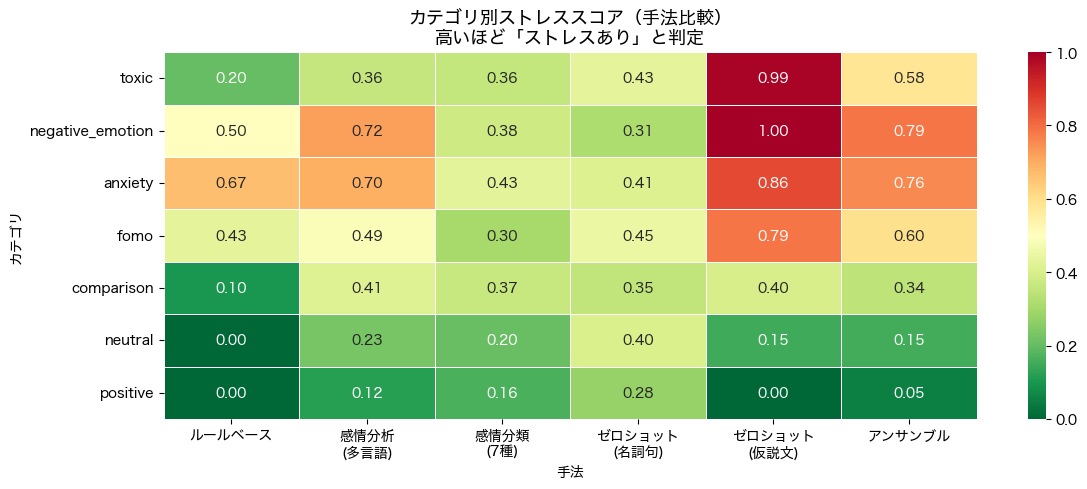

画像を research/data/ に保存しました


In [12]:
# 各手法のカテゴリ別平均スコアのヒートマップ
score_cols = ['rule_score', 'sent_neg', 'emotion_score', 'zs_noun_score', 'zs_sent_score', 'ensemble_score']
col_labels = ['ルールベース', '感情分析\n(多言語)', '感情分類\n(7種)', 'ゼロショット\n(名詞句)', 'ゼロショット\n(仮説文)', 'アンサンブル']

pivot = df.groupby('category')[score_cols].mean()
pivot.columns = col_labels

# 理想の検出順: toxic > negative_emotion > fomo > comparison > anxiety > neutral > positive
category_order = ['toxic', 'negative_emotion', 'anxiety', 'fomo', 'comparison', 'neutral', 'positive']
pivot = pivot.reindex([c for c in category_order if c in pivot.index])

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('カテゴリ別ストレススコア（手法比較）\n高いほど「ストレスあり」と判定', fontsize=13)
ax.set_xlabel('手法')
ax.set_ylabel('カテゴリ')
plt.tight_layout()
plt.savefig('../data/text_stress_comparison.png', dpi=150)
plt.show()
print('画像を research/data/ に保存しました')

In [ ]:
# 検出率の比較（何割の投稿をフラグしたか、カテゴリ別）
flag_cols = ['rule_flagged', 'sent_flagged', 'emotion_flagged', 'zs_noun_flagged', 'zs_sent_flagged', 'ensemble_flagged']
flag_labels = ['ルール', '感情分析', '感情分類', 'ZS名詞句', 'ZS仮説文', 'アンサンブル']

flag_pivot = df.groupby('category')[flag_cols].mean() * 100
flag_pivot.columns = flag_labels
flag_pivot = flag_pivot.reindex([c for c in category_order if c in flag_pivot.index])

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(flag_pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=0, vmax=100, ax=ax, linewidths=0.5)
ax.set_title('カテゴリ別フラグ率（%）\n高いほど「ストレスあり」と判定した割合が高い', fontsize=13)
ax.set_xlabel('手法')
ax.set_ylabel('カテゴリ')
plt.tight_layout()
plt.show()

print('\n--- 理想的な検出パターン ---')
print('toxic / negative_emotion / anxiety / fomo / comparison → 高フラグ率（🔴）')
print('neutral / positive → 低フラグ率（⚪）')
print('この理想に近い手法が、ストレス判定として最も優れている')

---
## 考察・まとめ

### 各手法の評価軸

| 手法 | toxic | negative_emotion | fomo/comparison | 誤検知（neutral/pos） |
|------|-------|-----------------|-----------------|----------------------|
| ルールベース | 中〜高 | 低（辞書次第） | 低 | 低 |
| 極性辞書（oseti） | 中 | 中（日本語） | 低 | 中 |
| 感情分析（多言語） | 高 | 高 | 中 | 中 |
| 感情分類（7種） | 高 | 高（英語） | 低 | 低 |
| ZS 名詞句 | 高 | 低 | 低 | 低 |
| ZS 仮説文 | 高 | 高 | 中〜高 | 中 |
| アンサンブル | 高 | 高 | 中 | 中 |

### SNS ストレス低減への推奨アーキテクチャ（仮説）

```
Layer 1: ルールベース
  → 即時・低コスト。明示的有害ワードに対応

Layer 2a: 感情分析モデル（多言語）
  → 日本語・英語のネガティブ感情全般をカバー

Layer 2b: ゼロショット（仮説文型）
  → FOMO・比較・不安誘発など文脈的ストレスをカバー
  → ユーザーが仮説文を自由に編集できる

Layer 3（オプション）: Perspective API
  → 高精度の毒性スコアが必要な場合のみ
```

### 今後の実験課題

1. **日本語特化**: 感情分類モデルの日本語版ファインチューニング
2. **ユーザー適応**: 個人ごとのフィードバックでモデルを個人化する
3. **文脈考慮**: 投稿単体でなくスレッド全体でストレスを判定
4. **実験的評価**: 実際のユーザーが「ストレスを感じた」と報告した投稿でモデルを評価
5. **閾値の最適化**: F1スコアを最大化する閾値をデータドリブンで決定